<a href="https://colab.research.google.com/github/AP-Common-Projects/nanograd/blob/main/engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Todo List

I. Create the built-in functions for repr, add and mul

II. Create the children and operation representation method

III. Study Graphviz and start representing these using Graphviz, see where you did wrong

IV. Tune up the functions and fix your mistakes, and look up the claude chat to see what's next

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import math

In [22]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self.label = label

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    return out

In [19]:
a = Value(4)
b = Value(3)

c = a * b
print(c)
print(c._prev)

Value(data=12)
{Value(data=4), Value(data=3)}


## Graphviz visualization

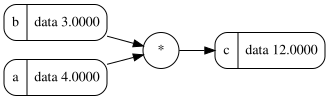

In [27]:
from graphviz import Digraph

def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    label = "{ %s | data %.4f }" % (n.label, n.data)
    if n._op:
        dot.node(name=uid, label=label, shape='Mrecord')
        dot.node(name=uid + n._op, label=n._op, shape='circle')
        dot.edge(uid + n._op, uid)
    else:
        dot.node(name=uid, label=label, shape='Mrecord')

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

# Re-create c with labels so they show up in the graph
a = Value(4, label='a')
b = Value(3, label='b')
c = a * b; c.label = 'c'

draw_dot(c)